**Geração de pontos 2D usando umadistribuição Gaussiana multivariada**

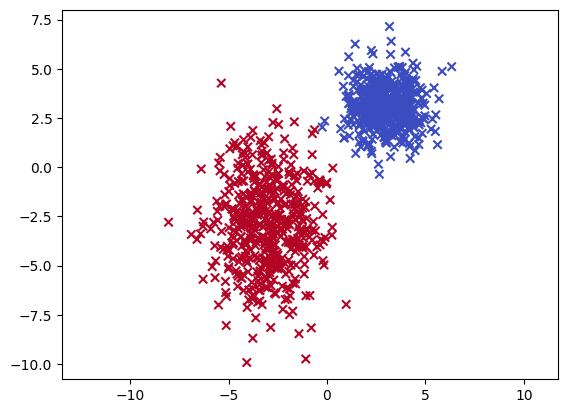

In [158]:
import matplotlib.pyplot as plt
import numpy as np
import random

mean = [3, 3]
cov = [[1 , 0], [0, 1]]
a = np.random.multivariate_normal(mean, cov, 500).T
mean = [-3, -3]
cov = [[2 , 0], [0, 5]]
b = np.random.multivariate_normal(mean, cov, 500).T
c = np.concatenate((a, b) , axis = 1)
c = c.T
etiqueta_a = np.ones((a.shape[1], 1))
etiqueta_b = np.full((b.shape[1], 1), 2)
etiquetas = np.vstack((etiqueta_a, etiqueta_b))
c = np.hstack((c, etiquetas))
np.random. shuffle(c)
c = c.T
x = c[0]
y = c[1]
etiquetas = c[2]
plt.scatter(x, y, c=etiquetas, cmap='coolwarm', marker='x')
plt.axis ( 'equal' )
plt.show()
np.savetxt('conjunto_de_etiquetas.txt', c.T, fmt='%.3f', delimiter=',', header='x,y,etiqueta', comments='')

**Implementação do algoritmo K-Means (1.2)**

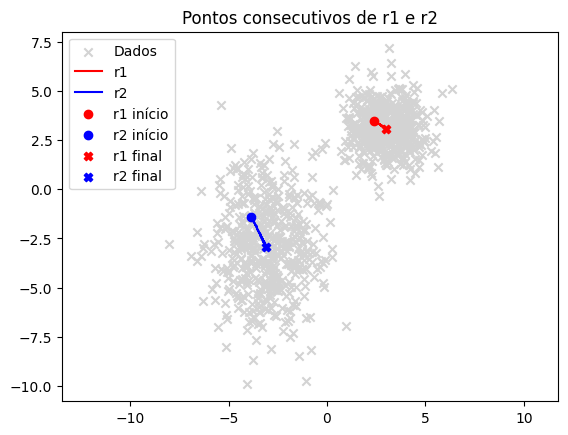

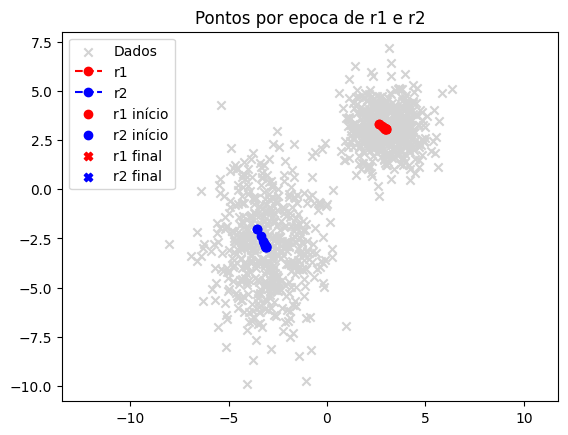

In [159]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.001
num_epocas = 10

r1_update = []
r2_update = []
r1_final = []
r2_final = []

for epoca in range(num_epocas):
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            r1 = (1-alpha) * r1 + alpha * x
            r1_update.append(r1.copy())
        else:
            r2 = (1-alpha) * r2 + alpha * x
            r2_update.append(r2.copy())
    r1_final.append(r1.copy())
    r2_final.append(r2.copy())

r1_update = np.array(r1_update)
r2_update = np.array(r2_update)
r1_final = np.array(r1_final)
r2_final = np.array(r2_final)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_update[:,0], r1_update[:,1], 'r-', label='r1')
plt.plot(r2_update[:,0], r2_update[:,1], 'b-', label='r2')
plt.scatter(r1_update[0,0], r1_update[0,1], c='red', marker='o', label='r1 início')
plt.scatter(r2_update[0,0], r2_update[0,1], c='blue', marker='o', label='r2 início')
plt.scatter(r1_update[-1,0], r1_update[-1,1], c='red', marker='X', label='r1 final')
plt.scatter(r2_update[-1,0], r2_update[-1,1], c='blue', marker='X', label='r2 final')
plt.title("Pontos consecutivos de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_final[:,0], r1_final[:,1], 'ro--', label='r1')
plt.plot(r2_final[:,0], r2_final[:,1], 'bo--', label='r2')
plt.scatter(r1_final[0,0], r1_final[0,1], c='red', marker='o', label='r1 início')
plt.scatter(r2_final[0,0], r2_final[0,1], c='blue', marker='o', label='r2 início')
plt.scatter(r1_final[-1,0], r1_final[-1,1], c='red', marker='X', label='r1 final')
plt.scatter(r2_final[-1,0], r2_final[-1,1], c='blue', marker='X', label='r2 final')
plt.title("Pontos por epoca de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()
    


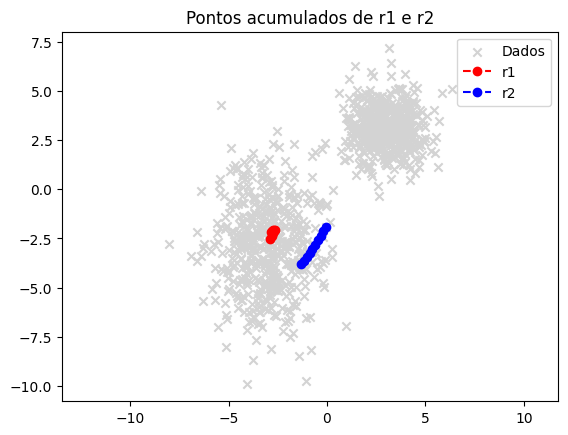

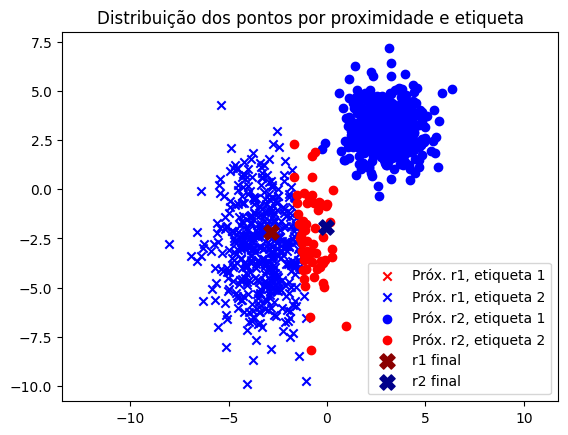

In [160]:
import matplotlib.pyplot as plt
import numpy as np
import random

pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas= pontos[:, 0:2]
etiquetas = pontos[:, 2]

r1 = coordenadas[random.randint(0 , len(coordenadas)-1)]
r2 = coordenadas[random.randint(0 , len(coordenadas)-1)]

alpha = 0.05
num_epocas = 10


r1_acc = []
r2_acc = []

for epoca in range(num_epocas):
    d1_total = np.zeros(2)
    d2_total = np.zeros(2)
    n1 = 0
    n2 = 0
    for x in coordenadas:
        d1 = np.sqrt(np.sum((x-r1) ** 2))
        d2 = np.sqrt(np.sum((x-r2) ** 2))

        if d1 < d2:
            d1_total += (x - r1)
            n1 += 1
        else:
            d2_total += (x - r2)
            n2 += 1

    r1 += alpha * (d1_total / n1)
    r2 += alpha * (d2_total / n2)        
    r1_acc.append(r1.copy())
    r2_acc.append(r2.copy())


r1_acc = np.array(r1_acc)
r2_acc = np.array(r2_acc)

plt.scatter(coordenadas[:,0], coordenadas[:,1], c='lightgray', marker='x', label='Dados')
plt.plot(r1_acc[:,0], r1_acc[:,1], 'ro--', label='r1')
plt.plot(r2_acc[:,0], r2_acc[:,1], 'bo--', label='r2')
plt.title("Pontos acumulados de r1 e r2")
plt.legend()
plt.axis('equal')
plt.show()

dist_r1 = np.sqrt(np.sum((coordenadas-r1) ** 2, axis=1))
dist_r2 = np.sqrt(np.sum((coordenadas-r2) ** 2, axis=1))
prox_r1 = dist_r1 < dist_r2  


r1_etiqueta1 = (prox_r1) & (etiquetas == 1)
r1_etiqueta2 = (prox_r1) & (etiquetas == 2)
r2_etiqueta1 = (~prox_r1) & (etiquetas == 1)
r2_etiqueta2 = (~prox_r1) & (etiquetas == 2)


plt.scatter(coordenadas[r1_etiqueta1,0], coordenadas[r1_etiqueta1,1], c='red', marker='x', label='Próx. r1, etiqueta 1')
plt.scatter(coordenadas[r1_etiqueta2,0], coordenadas[r1_etiqueta2,1], c='blue', marker='x', label='Próx. r1, etiqueta 2')
plt.scatter(coordenadas[r2_etiqueta1,0], coordenadas[r2_etiqueta1,1], c='blue', marker='o', label='Próx. r2, etiqueta 1')
plt.scatter(coordenadas[r2_etiqueta2,0], coordenadas[r2_etiqueta2,1], c='red', marker='o', label='Próx. r2, etiqueta 2')

plt.scatter(r1[0], r1[1], c='darkred', s=120, marker='X', label='r1 final')
plt.scatter(r2[0], r2[1], c='darkblue', s=120, marker='X', label='r2 final')

plt.title("Distribuição dos pontos por proximidade e etiqueta")
plt.legend()
plt.axis('equal')
plt.show()

**Exercicio 2 - Clustering aglomerativo hierárquico**

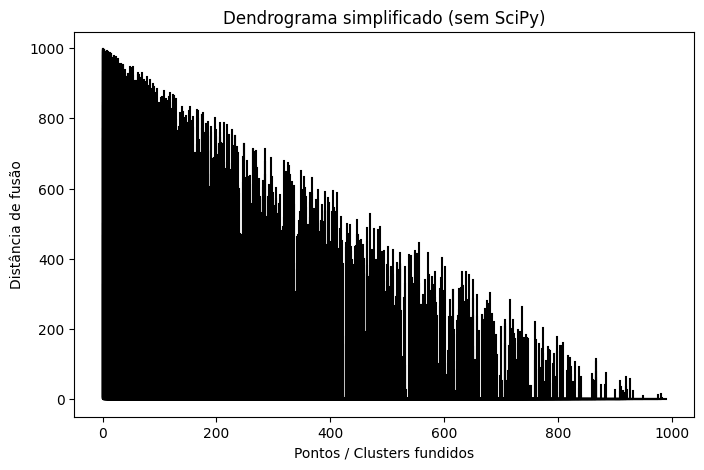

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Gerar ou carregar dados ---
pontos = np.loadtxt('conjunto_de_etiquetas.txt', delimiter=',', skiprows=1)
coordenadas = pontos[:, 0:2]

# --- Cópia para trabalhar ---
X = coordenadas.copy()

# --- Guardar histórico de fusões ---
fusoes = []  # lista de (p1, p2, distancia, novo_indice)
etapa = 0

while len(X) > 2:
    dist_min = np.inf
    p1, p2 = None, None

    # Encontrar o par mais próximo
    for i in range(len(X)):
        for j in range(i + 1, len(X)):
            dist = np.sqrt(np.sum((X[i] - X[j])**2))
            if dist < dist_min:
                dist_min = dist
                p1, p2 = i, j

    # Guardar a fusão (para o dendrograma)
    fusoes.append((p1, p2, dist_min, len(X)))

    # Calcular média e atualizar X
    novo_ponto = (X[p1] + X[p2]) / 2
    X = np.delete(X, [p1, p2], axis=0)
    X = np.vstack([X, novo_ponto])

    etapa += 1

# --- Gerar dendrograma simples ---
plt.figure(figsize=(8, 5))
y = 0
for i, (p1, p2, dist, n) in enumerate(fusoes):
    plt.plot([p1, p1, p2, p2], [y, dist, dist, y], c='black')
    y += 1

plt.title("Dendrograma simplificado ")
plt.xlabel("Pontos / Clusters fundidos")
plt.ylabel("Distância de fusão")
plt.show()
